# 乃杰拉取线上数据JSON分析

In [8]:
import sys
import json
import re
import copy

js_file = 'data_json/20250101前一万条.json'
out_js_file = 'data_json/20250101前一万条.filter.json'

json_data = json.load(open(js_file, 'r', encoding='utf-8'))


print(len(json_data))

print(type(json_data), json_data.keys())

4
<class 'dict'> dict_keys(['took', 'timed_out', '_shards', 'hits'])


In [17]:
def read_asr_json(json_path):
    json_data = json.load(open(json_path, 'r', encoding='utf-8'))
    
    if 'hits' not in json_data or 'hits' not in json_data['hits']:
        print(f'Error: json_data no have [hits][hits] key ')
        return None
    
    speech_infos = json_data['hits']['hits']
    print('total {} speech'.format(len(speech_infos)))
    
    datas = []
    for speech_info in speech_infos:
        speech_id = speech_info['_id']
        speech_asr = speech_info['_source']['result']
        speech_dur = speech_info['_source']['duration']
        app_name = speech_info['_source']['channel']
        use_id = speech_info['_source']['userCode']
        data = {
            'speech_id': speech_id,
            'speech_asr': speech_asr,
            'speech_dur': speech_dur,
            'app_name': app_name,
            'use_id': use_id
        }
        datas.append(data)
    
    print(datas[:5])
    return datas, json_data

def del_data_from_json(json_data, save_datas):
    speech_ids = [data['speech_id'] for data in save_datas]
    print(speech_ids[:10])
    print(type(speech_ids), len(speech_ids), type(speech_ids[0]))
    speech_idx1 = speech_ids
    speech_ids = set(speech_ids)
    
    
    out_json_data = copy.deepcopy(json_data)
    speech_infos = json_data['hits']['hits']
    print("total {} speech, will select {} speech".format( len(speech_infos), len(speech_ids) ))
    for speech_info in speech_infos:
        speech_id = speech_info['_id']
        if speech_id not in speech_ids:
            out_json_data['hits']['hits'].remove(speech_info)
    
    return out_json_data
    

def clean_text(text):    
    
    text_no_punct = re.sub(r'[^\w\s]', '', text)
    # 移除所有标点符号
    # \w 匹配字母数字及下划线；因此 [^\w] 匹配非字母数字及非下划线字符
    text_standardized_spaces = re.sub(r'\s+', ' ', text_no_punct).strip()
    
    return text_standardized_spaces

def filter_data(datas, min_dur=3, max_dur=20, min_txt_len=2, max_txt_len=60, max_speed=10):
    out_datas = []
    for data in datas:
        speech_dur = data['speech_dur']
        speech_asr = data['speech_asr']
        
        speech_asr = clean_text(speech_asr)
        
        if speech_dur < min_dur or speech_dur > max_dur:
            continue
        if len(speech_asr) < min_txt_len or len(speech_asr) > max_txt_len:
            continue
        if len(speech_asr) / speech_dur > max_speed:
            continue
        
        out_datas.append(data)
    print("filter dur txt_len speed :  {} / {} = {}".format(len(out_datas), len(datas), len(out_datas) / len(datas) ))
    return out_datas




def filter_txts(datas):
    
    patterns = []
    patterns.append( re.compile(r'\d{4,}') )    # 匹配超过4个数字的文本
    patterns.append( re.compile(r'yt\d{2,}') )    # 匹配超过4个数字的文本
    patterns.append( re.compile(r'^\d+$') )     # 匹配纯数字的文本
    patterns.append( re.compile(r'^[\d\s]+$') ) # 匹配纯数字和空格的文本 
    
    out_datas = []
    
    for data in datas:
        speech_asr = data['speech_asr']
        
        speech_asr = clean_text(speech_asr)
        
        is_delete = False
        for pattern in patterns:
            if pattern.search(speech_asr):
                is_delete = True
                break
        
        if is_delete:
            continue
        
        out_datas.append(data)
    print("filter number_txt :  {} / {} = {}".format(len(out_datas), len(datas), len(out_datas) / len(datas) ))
    return out_datas






In [18]:
print(json_data.keys())
a = json_data['hits']['hits']
print(type(a), len(a))
print(a[0])

datas, json_data = read_asr_json(js_file)
filter_datas = filter_data(datas)


# print(f'filter {len(filter_datas)} from {len(datas)} ratio {len(filter_datas)/len(datas)}')

filter_datas = filter_txts(filter_datas)

print(f'total filter {len(filter_datas)} from {len(datas)} ratio {len(filter_datas)/len(datas)}')

filter_out_json_data = del_data_from_json(json_data, filter_datas)

speech_infos = filter_out_json_data['hits']['hits']
print('total {} speech'.format(len(speech_infos)))


json.dump(filter_out_json_data, open(out_js_file, 'w'), indent=4, ensure_ascii=False)

with open('out.txt', 'w') as f:
    for data in filter_datas:
        speech_id = data['speech_id']
        text = data['speech_asr']
        
        f.write(f'{speech_id}\t{text}\n')

dict_keys(['took', 'timed_out', '_shards', 'hits'])
<class 'list'> 10000
{'_index': 'speech-oneword-record-20250101', '_type': '_doc', '_id': 'zS1yHZQBGqEj3P2NFd6y', '_score': None, '_source': {'result': '新建一个大堂签收位置。', 'duration': 3.84, 'size': 120, 'channel': 'XingZhe_app_ad_ali', 'userCode': '02259308', 'objectId': 'qYCFOsZdg+tLbh1MJhmHVQW43L6exlS32JBQK4m8q0YOLYKc1dIGf27F+mg5TG/VPnTnkNeqAM0JSrZtJJuzT5D9OtzcKkoVJjMKhmfpNp4OCdH9fN543u79zOUN3esS', 'nowTime': '2024-12-31T16:00:03.472Z'}, 'sort': [1735660803472]}
total 10000 speech
[{'speech_id': 'zS1yHZQBGqEj3P2NFd6y', 'speech_asr': '新建一个大堂签收位置。', 'speech_dur': 3.84, 'app_name': 'XingZhe_app_ad_ali', 'use_id': '02259308'}, {'speech_id': 'ospyHZQBmI0fmXAeS0nE', 'speech_asr': '叉1113 。', 'speech_dur': 2.52, 'app_name': 'XingZhe_app_ad_ali', 'use_id': '01660616'}, {'speech_id': '_etyHZQBksv5ZkOdTGxL', 'speech_asr': '大唐。', 'speech_dur': 2.22, 'app_name': 'XingZhe_app_ad_ali', 'use_id': '02259308'}, {'speech_id': 'pcpyHZQBmI0fmXAeZ0kx', 'speec

ori avg-speech_dur : 2.6 , ori avg-txt_len : 10.7
app_names : {'XingZhe_app_ad_ali', 'WDGJ_APP_NEW', 'XingZhe_app_android', 'ELu3C7cH4vY2mUsSiswZf', 'XingZhe_app_ios', 'JSC_APP', 'YZ_APP_NEW'}
filter 0.2779 data
avg_x speech_dur : 4.7 , avg_y txt_len : 16.0
[2.8645833333333335, 1.5625, 2.380952380952381, 1.9444444444444444, 4.411764705882353, 1.9021739130434783, 1.0, 2.9605263157894735, 1.4035087719298245, 1.3468013468013467, 3.5256410256410255, 1.8867924528301885, 3.1380753138075312, 3.6796536796536796, 4.279279279279279, 3.7777777777777777, 4.417670682730924, 4.0, 3.935185185185185, 3.614457831325301, 3.7777777777777777, 3.9583333333333335, 3.7777777777777777, 3.990610328638498, 3.75, 4.1062801932367154, 3.541666666666667, 4.292929292929293, 4.016064257028112, 4.601226993865031, 4.228855721393035, 4.292929292929293, 3.7777777777777777, 3.7280701754385968, 4.398148148148148, 4.228855721393035, 4.427083333333334, 4.1062801932367154, 3.373015873015873, 4.398148148148148, 4.9019607843137

Text(0.5, 0, 'speech_dur')

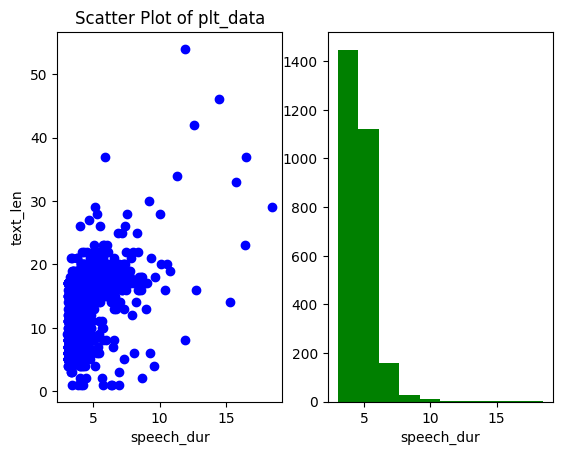

In [102]:
speech_durs = [data['speech_dur'] for data in datas]
speech_txt_len = [len(data['speech_asr']) for data in datas]

avg_x = sum(speech_durs) / len(speech_durs)
avg_y = sum(speech_txt_len) / len(speech_txt_len)
print(f'ori avg-speech_dur : {avg_x:.1f} , ori avg-txt_len : {avg_y:.1f}')


plt_data = [(x, y) for x, y in zip(speech_durs, speech_txt_len) if x > 3 and x < 20  and y > 0 and y < 100  and y/x<10]
txt_rates = [y/x for x, y in plt_data if x > 0 and  y > 0 and y/x < 10]
app_names = set([data['app_name'] for data in datas])
print(f'app_names : {app_names}')
print('filter {} data'.format(len(plt_data)/len(speech_durs)))

import matplotlib.pyplot as plt

plt.subplot(1, 2, 1) 

x_data = [x for x, y in plt_data]
y_data = [y for x, y in plt_data]
avg_x = sum(x_data) / len(x_data)
avg_y = sum(y_data) / len(y_data)
print(f'avg_x speech_dur : {avg_x:.1f} , avg_y txt_len : {avg_y:.1f}')
plt.scatter(x_data, y_data, color='blue', label='Data Points')

plt.title('Scatter Plot of plt_data')
plt.xlabel('speech_dur')
plt.ylabel('text_len')

plt.subplot(1, 2, 2)
plt.hist(x_data,  color='green',  label='Histogram')
print(txt_rates[:50])
plt.xlabel('speech_dur')

In [117]:
# for data in datas:
#     speech_dur = data["speech_dur"]
#     txt = data['speech_asr']
#     is_break = False
#     if len(txt) > 1000:
#         print(data)
#         is_break = True
#     if len(txt)/ speech_dur > 10:
#         print(f'dur {speech_dur}, txt-len {len(txt)} rate {len(txt)/ speech_dur}')
#         print(data)
#         is_break = True
    
#     if is_break:
#         break
    

txts = [data['speech_asr'] for data in filter_datas]  
print(txts[:30])


['新建一个大堂签收位置。', '最新更新的内容。', '丰源大厦一楼。', '行者，今天更新了。更新的内容是什么。', '南谷公寓一楼。', '或门卫。', '中山佳悦菜鸟驿站。', '锦和加州丰巢柜。', '找一生浙江二手。', '上报破损件。', '航空件为什么会产生罚款', '怎样坚定，无可不息', '是的，机器的我不行，你呀，快去快去给他，快给给我，他有权进', '10 月份的投入有几个。', '10 月份的投诉有几个。', '10 月份的开心果有几个。', '从邯郸到美乐成都', '东莞中心进港线路时效分析。', '味地', '美味。', '就是有多少个配件。', '江苏省寄到河北省的运费。', '小圆小圆儿，我今儿个有投诉的。', '恒大名都生产驿站', '步行街菜鸟驿站。', '一号楼2单元9层客户。', '一号楼2单元11 层西。', '29 号以上补录签收。', '补录签收29 号以上。', '嗯，有有到未派。']


In [114]:
import re

def clean_text1(text):

    text_no_punct = re.sub(r'[^\w\s]', '', text)
    # 移除所有标点符号
    # \w 匹配字母数字及下划线；因此 [^\w] 匹配非字母数字及非下划线字符
    text_standardized_spaces = re.sub(r'\s+', ' ', text_no_punct).strip()
    
    return text_standardized_spaces

# 示例文本
sample_text = "你好，你是谁，三等，, Hello, world! This is a test text 123."

cleaned_text = clean_text1(sample_text)

print("原始文本:", sample_text)
print("处理后的文本:", cleaned_text)

原始文本: 你好，你是谁，三等，, Hello, world! This is a test text 123.
处理后的文本: 你好你是谁三等 Hello world This is a test text 123


## 分析乃杰筛选后的文本

(array([ 36., 116., 210., 338., 388., 255., 133.,  68.,  64.,  28.]),
 array([ 0. ,  1.9,  3.8,  5.7,  7.6,  9.5, 11.4, 13.3, 15.2, 17.1, 19. ]),
 <BarContainer object of 10 artists>)

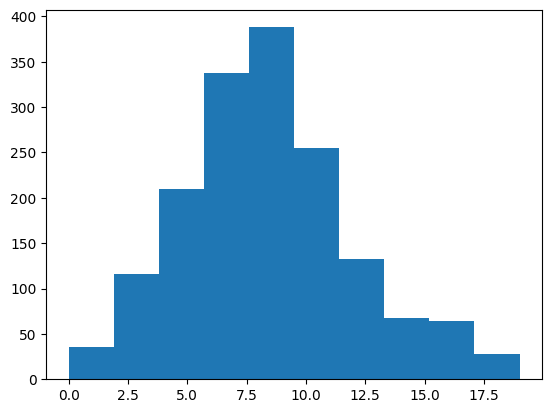

In [11]:
text_file = '/home/zhangjiayuan/temp/a'

texts = []
with open(text_file, 'r') as f:
    for line in f:
        texts.append(line.strip())



text_lens = [len(text) for text in texts if len(text) < 20]
text_lens.sort()
import matplotlib.pyplot as plt

plt.hist(text_lens, bins=10)


# 给自发提供offline结果

利用驾驶舱之前提供的25万音频跑跑线上的结果， 把每个offline片段当做一行

In [10]:
import sys
import os
import glob

in_dir = '/home/zhangjiayuan/program/yto/yto-asr-core/asr-engine/runtime/result/ytogpt_data0702_25k'

seg_files = glob.glob(os.path.join(in_dir, '*.seg.txt'))
print(f'get {len(seg_files)} seg files')

out_file = f'{in_dir}/all_segs.txt'

datas = []
for i, seg_file in enumerate(seg_files):
    utt = os.path.basename(seg_file).replace(".seg.txt", "")
    seg_texts = []
    with open(seg_file, 'r') as f:
        for line in f:
            if "text-seg:" in line:
                buff = line.strip().split()
                seg_txt = ""
                for i in range(len(buff)-1):
                    if buff[i] == "text-seg:":
                        seg_txt = buff[i+1]
                if seg_txt != "":
                    seg_texts.append(seg_txt)
                
    # print(f'{utt} {seg_texts}')
    datas.append([utt, seg_texts])
    # if i >=10:
    #     break

with open(out_file, 'w') as f:
    for utt, seg_texts in datas:
        for i, seg_txt in enumerate(seg_texts):
            seg_txt = seg_txt.replace(',', " ")
            f.write(f'{utt},{i},{seg_txt}\n')

get 24974 seg files
